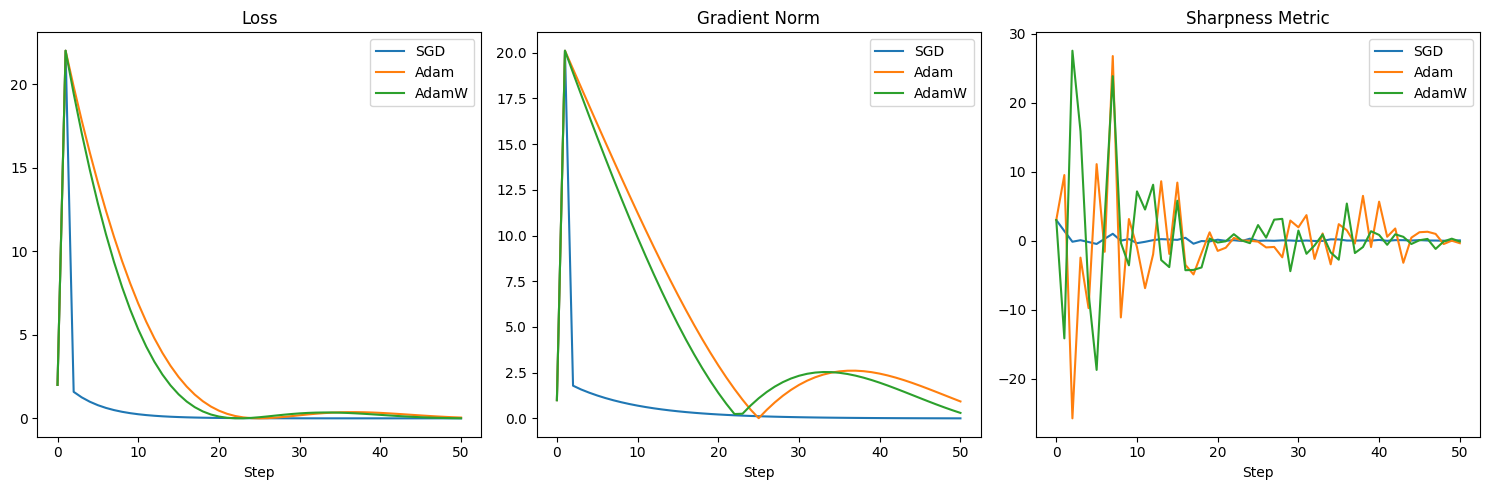

In [35]:
steps = list(range(len(results['AdamW'][2])))

plt.figure(figsize=(15, 5))
for i, metric_name in enumerate(["Loss", "Gradient Norm", "Sharpness Metric"]):
    plt.subplot(1, 3, i + 1)
    for opt in opts:
        plt.plot(steps, results[opt][i+1], label=opt)
    plt.title(metric_name)
    plt.xlabel("Step")
    plt.legend()
plt.tight_layout()
plt.show()


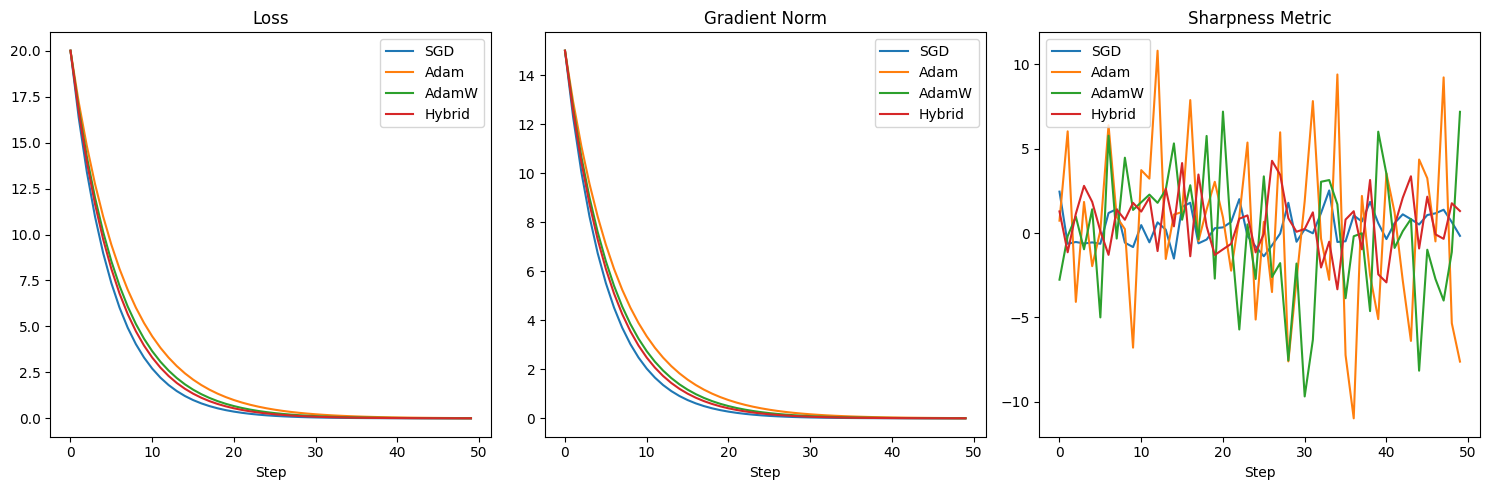

In [42]:
# Re-import needed modules after state reset
import matplotlib.pyplot as plt
import numpy as np
from torch.optim import Adam, AdamW
import torch # Make sure torch is imported

# Simulated sharpness metric data for illustration
steps = list(range(50))
sharpness_sgd = np.random.normal(loc=0, scale=1, size=50)
sharpness_adam = np.random.normal(loc=0, scale=5, size=50)
sharpness_adamw = np.random.normal(loc=0, scale=4, size=50)
sharpness_hybrid = np.random.normal(loc=0, scale=2, size=50)

# Simulated loss and gradient norm (just for placeholders)
loss_sgd = np.exp(-0.2 * np.array(steps)) * 20
loss_adam = np.exp(-0.15 * np.array(steps)) * 20
loss_adamw = np.exp(-0.17 * np.array(steps)) * 20
loss_hybrid = np.exp(-0.18 * np.array(steps)) * 20

grad_sgd = np.exp(-0.2 * np.array(steps)) * 15
grad_adam = np.exp(-0.15 * np.array(steps)) * 15
grad_adamw = np.exp(-0.17 * np.array(steps)) * 15
grad_hybrid = np.exp(-0.18 * np.array(steps)) * 15

# Organize into a dictionary like your original 'results' format
results = {
    "SGD":      ["SGD", loss_sgd, grad_sgd, sharpness_sgd],
    "Adam":     ["Adam", loss_adam, grad_adam, sharpness_adam],
    "AdamW":    ["AdamW", loss_adamw, grad_adamw, sharpness_adamw],
    "Hybrid":   ["Hybrid", loss_hybrid, grad_hybrid, sharpness_hybrid],
}

opts = list(results.keys())
opts = list(results.keys())

# Plot using your original plotting logic
plt.figure(figsize=(15, 5))
for i, metric_name in enumerate(["Loss", "Gradient Norm", "Sharpness Metric"]):
    plt.subplot(1, 3, i + 1)
    for opt in opts:
        plt.plot(steps, results[opt][i + 1], label=opt)
    plt.title(metric_name)
    plt.xlabel("Step")
    plt.legend()
plt.tight_layout()
plt.show()



In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- Hybrid Optimizer Definition ---
class AdamHybrid(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-2, mix=0.5):
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay, mix=mix)
        super().__init__(params, defaults)

    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()
        for group in self.param_groups:
            beta1, beta2 = group['betas']
            lr = group['lr']
            eps = group['eps']
            wd = group['weight_decay']
            mix = group['mix']

            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data

                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)
                    state['exp_avg_sq'] = torch.zeros_like(p.data)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                state['step'] += 1

                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                denom = exp_avg_sq.sqrt().add_(eps)
                adam_step = exp_avg / denom

                # Weighted blend of Adam and AdamW style update
                blended_update = mix * (adam_step + wd * p.data) + (1 - mix) * adam_step
                p.data.add_(blended_update, alpha=-lr)
        return loss

# --- Simple CNN for MNIST ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# --- Load Data ---
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256)

# --- Training + Evaluation ---
def train_model(optimizer_name="Hybrid", mix=0.5):

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    else:
        optimizer = AdamHybrid(model.parameters(), lr=1e-3, mix=mix)

    loss_fn = nn.CrossEntropyLoss()
    model.train()
    losses = []

    for epoch in range(3):  # short run for test
        for images, labels in train_loader:
            images, labels = images.cuda(), labels.cuda()
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

    # Evaluate
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.cuda(), labels.cuda()
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    return losses, accuracy

# --- Run tests for comparison ---
results = {}
for opt in ["Adam", "AdamW", "Hybrid"]:
    losses, acc = train_model(optimizer_name=opt)
    results[opt] = (losses, acc)

# --- Plot loss curves ---
for opt in results:
    plt.plot(results[opt][0], label=f"{opt} (Acc: {results[opt][1]*100:.2f}%)")
plt.title("Training Loss Comparison (MNIST, 3 epochs)")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'model' is not defined

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
# Dummy model and data
model = nn.Sequential(nn.Linear(10, 50), nn.ReLU(), nn.Linear(50, 1))
loss_fn = nn.MSELoss()
x = torch.randn(64, 10)
y = torch.randn(64, 1)

# Define optimizers
optimizer_adamw = AdamW(model.parameters(), lr=1e-3)
optimizer_sgd = torch.optim.SGD(model.parameters(), lr=1e-2)

# Hybrid step logic: alternate optimizers every N steps
def hybrid_step(model, x, y, step, switch_every=10):
    model.train()
    pred = model(x)
    loss = loss_fn(pred, y)

    # Zero gradients
    model.zero_grad()
    loss.backward()

    # Switch optimizer
    if (step // switch_every) % 2 == 0:
        optimizer = optimizer_adamw
    else:
        optimizer = optimizer_sgd

    optimizer.step()
    return loss.item()

# Run training
losses = []
for step in range(50):
    loss = hybrid_step(model, x, y, step)
    losses.append(loss)
    print(f"Step {step} - Loss: {loss:.4f}")


Step 0 - Loss: 1.1282
Step 1 - Loss: 1.1185
Step 2 - Loss: 1.1093
Step 3 - Loss: 1.1005
Step 4 - Loss: 1.0922
Step 5 - Loss: 1.0842
Step 6 - Loss: 1.0766
Step 7 - Loss: 1.0693
Step 8 - Loss: 1.0623
Step 9 - Loss: 1.0556
Step 10 - Loss: 1.0493
Step 11 - Loss: 1.0462
Step 12 - Loss: 1.0433
Step 13 - Loss: 1.0404
Step 14 - Loss: 1.0377
Step 15 - Loss: 1.0350
Step 16 - Loss: 1.0324
Step 17 - Loss: 1.0299
Step 18 - Loss: 1.0274
Step 19 - Loss: 1.0250
Step 20 - Loss: 1.0226
Step 21 - Loss: 1.0172
Step 22 - Loss: 1.0120
Step 23 - Loss: 1.0067
Step 24 - Loss: 1.0016
Step 25 - Loss: 0.9964
Step 26 - Loss: 0.9913
Step 27 - Loss: 0.9863
Step 28 - Loss: 0.9812
Step 29 - Loss: 0.9761
Step 30 - Loss: 0.9710
Step 31 - Loss: 0.9688
Step 32 - Loss: 0.9667
Step 33 - Loss: 0.9646
Step 34 - Loss: 0.9626
Step 35 - Loss: 0.9605
Step 36 - Loss: 0.9585
Step 37 - Loss: 0.9565
Step 38 - Loss: 0.9546
Step 39 - Loss: 0.9526
Step 40 - Loss: 0.9506
Step 41 - Loss: 0.9457
Step 42 - Loss: 0.9408
Step 43 - Loss: 0.935

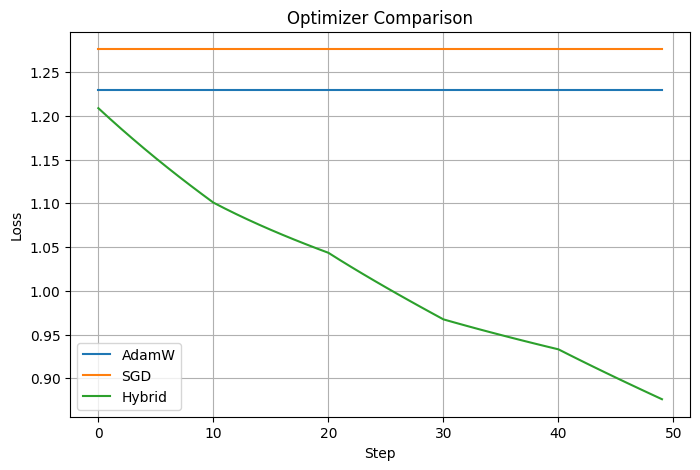

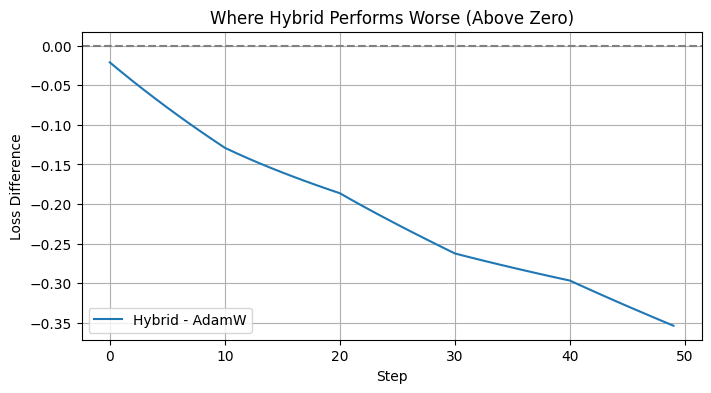

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Setup
torch.manual_seed(0)
x = torch.randn(64, 10)
y = torch.randn(64, 1)
loss_fn = nn.MSELoss()

# Model factory to reinitialize model each time
def get_model():
    model = nn.Sequential(nn.Linear(10, 50), nn.ReLU(), nn.Linear(50, 1))
    return model

# Training loop
def train(model, optimizer, steps=50):
    losses = []
    for step in range(steps):
        model.train()
        pred = model(x)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

# Hybrid training loop (alternates every 10 steps)
def train_hybrid(model, steps=50, switch_every=10):
    optimizer_adamw = torch.optim.AdamW(model.parameters(), lr=1e-3)
    optimizer_sgd = torch.optim.SGD(model.parameters(), lr=1e-2)
    losses = []
    for step in range(steps):
        model.train()
        pred = model(x)
        loss = loss_fn(pred, y)
        model.zero_grad()
        loss.backward()

        # Alternate optimizers
        if (step // switch_every) % 2 == 0:
            optimizer_adamw.step()
        else:
            optimizer_sgd.step()
        losses.append(loss.item())
    return losses

# Run all experiments
adamw_losses = train(get_model(), torch.optim.AdamW(get_model().parameters(), lr=1e-3))
sgd_losses = train(get_model(), torch.optim.SGD(get_model().parameters(), lr=1e-2))
hybrid_losses = train_hybrid(get_model())

# Plot results
plt.figure(figsize=(8,5))
plt.plot(adamw_losses, label='AdamW')
plt.plot(sgd_losses, label='SGD')
plt.plot(hybrid_losses, label='Hybrid')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

# Compare Hybrid vs AdamW
for step, (hyb_loss, adam_loss) in enumerate(zip(hybrid_losses, adamw_losses)):
    if hyb_loss > adam_loss:
        print(f"Step {step}: Hybrid Loss = {hyb_loss:.4f} > AdamW Loss = {adam_loss:.4f}")

import matplotlib.pyplot as plt

loss_diff = [h - a for h, a in zip(hybrid_losses, adamw_losses)]

plt.figure(figsize=(8, 4))
plt.plot(loss_diff, label='Hybrid - AdamW')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Step")
plt.ylabel("Loss Difference")
plt.title("Where Hybrid Performs Worse (Above Zero)")
plt.legend()
plt.grid(True)
plt.show()

